# Keypoint-Based Homography Pipeline Demo with Ball Detection

This notebook demonstrates the full pipeline:
1. **Keypoint Detection** → Homography matrix (with temporal EMA smoothing)
2. **Team Color Analysis** → K-means jersey color clustering
3. **Perspective Transform** → Player projection onto pitch
4. **Ball Detection** → Dedicated YOLO ball model with trajectory trail
5. **Segmentation** → Deep analysis overlay

**Features**:
- Homography EMA smoothing (`SMOOTHING_ALPHA=0.4`) — reduces frame-to-frame jitter
- Team color analysis (K-means on jersey colors) — segregates players into teams
- Team-colored dots + legend on pitch canvas
- Team-colored bounding boxes on annotated frames
- **Ball detection** — dedicated `yolo_11_best.pt` model, ball bbox + projected dot + trajectory trail

Model paths:
- Keypoint: `../models/keypoint_model/26n_pipeline/no_aug/weights/best.pt`
- Player: `../models/player_model/best.pt`
- Segmentation: `../models/segmentation/best.pt`
- Ball: `../models/ball_model/yolo_11_best.pt`

In [21]:
# Imports
import sys
sys.path.insert(0, '..')

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

from app.keypoint_pipeline import KeypointPipeline
from app.keypoint_service import PitchKeypointMapper, KeypointHomographyComputer
from app.ball_service import BallDetector
from app.constants import *
from app.pitch import PitchArtist
from app.director import Director
from app.team_analyzer import TeamColorAnalyzer

%matplotlib inline
print('Imports loaded successfully.')

Imports loaded successfully.


## Configuration

Set your input video and model paths below.

In [22]:
# == USER INPUTS ==
SOURCE_VIDEO_PATH ="../data/test_data/FULL MATCH ｜ Croatia 1-1 Czechia ｜ VIP Tactical Camera ｜ EURO 2020 ｜ [KgQquW68E-Q].webm"
# SOURCE_VIDEO_PATH ="../FULL MATCH ｜ BETIS 3 vs 5 FC BARCELONA ｜ LALIGA 2025⧸26 MD15 🔵🔴 [93LPZJkCW2w].webm"


# Model paths
KEYPOINT_MODEL_PATH = "../models/keypoint_model/26n_pipeline/no_aug/weights/best.pt"
PLAYER_MODEL_PATH = "../models/player_model/best.pt"
SEG_MODEL_PATH = "../models/segmentation/best.pt"
BALL_MODEL_PATH = "yolo26m.pt"

# Output directory
OUTPUT_DIR = Path("keypoint_demo_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Source video: {SOURCE_VIDEO_PATH}")
print(f"Keypoint model: {KEYPOINT_MODEL_PATH}")
print(f"Player model: {PLAYER_MODEL_PATH}")
print(f"Segmentation model: {SEG_MODEL_PATH}")
print(f"Ball model: {BALL_MODEL_PATH}")
print(f"Smoothing: alpha={SMOOTHING_ALPHA}, stability threshold={H_STABILITY_THRESHOLD}")
print(f"Team colors: enabled")

Source video: ../data/test_data/FULL MATCH ｜ Croatia 1-1 Czechia ｜ VIP Tactical Camera ｜ EURO 2020 ｜ [KgQquW68E-Q].webm
Keypoint model: ../models/keypoint_model/26n_pipeline/no_aug/weights/best.pt
Player model: ../models/player_model/best.pt
Segmentation model: ../models/segmentation/best.pt
Ball model: yolo26m.pt
Smoothing: alpha=0.4, stability threshold=0.15
Team colors: enabled


## Initialize Pipeline

In [23]:
# Initialize the full pipeline with team colors and ball detection
pipeline = KeypointPipeline(
    keypoint_model_path=KEYPOINT_MODEL_PATH,
    player_model_path=PLAYER_MODEL_PATH,
    seg_model_path=SEG_MODEL_PATH,
    ball_model_path=BALL_MODEL_PATH,
    enable_team_colors=True,  # Enables team color analysis + colored rendering
)

print("Pipeline initialized.")
print(f"  Enable team colors: {pipeline.team_analyzer is not None}")
print(f"  Ball detector: {pipeline.ball_detector is not None}")

Pipeline initialized.
  Enable team colors: True
  Ball detector: True


## Test on a Single Frame

Let's process a single frame to verify the pipeline works correctly.

In [24]:
# Open video and grab a frame
cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)

# Seek to frame 300 (same as original del.ipynb)
frame_num=0
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)

ret, frame = cap.read()
if not ret:
    raise RuntimeError(f"Could not read frame from {SOURCE_VIDEO_PATH}")

cap.release()

frame_h, frame_w = frame.shape[:2]
print(f"Frame size: {frame_w}x{frame_h}")

Frame size: 1920x1080


### Original Frame

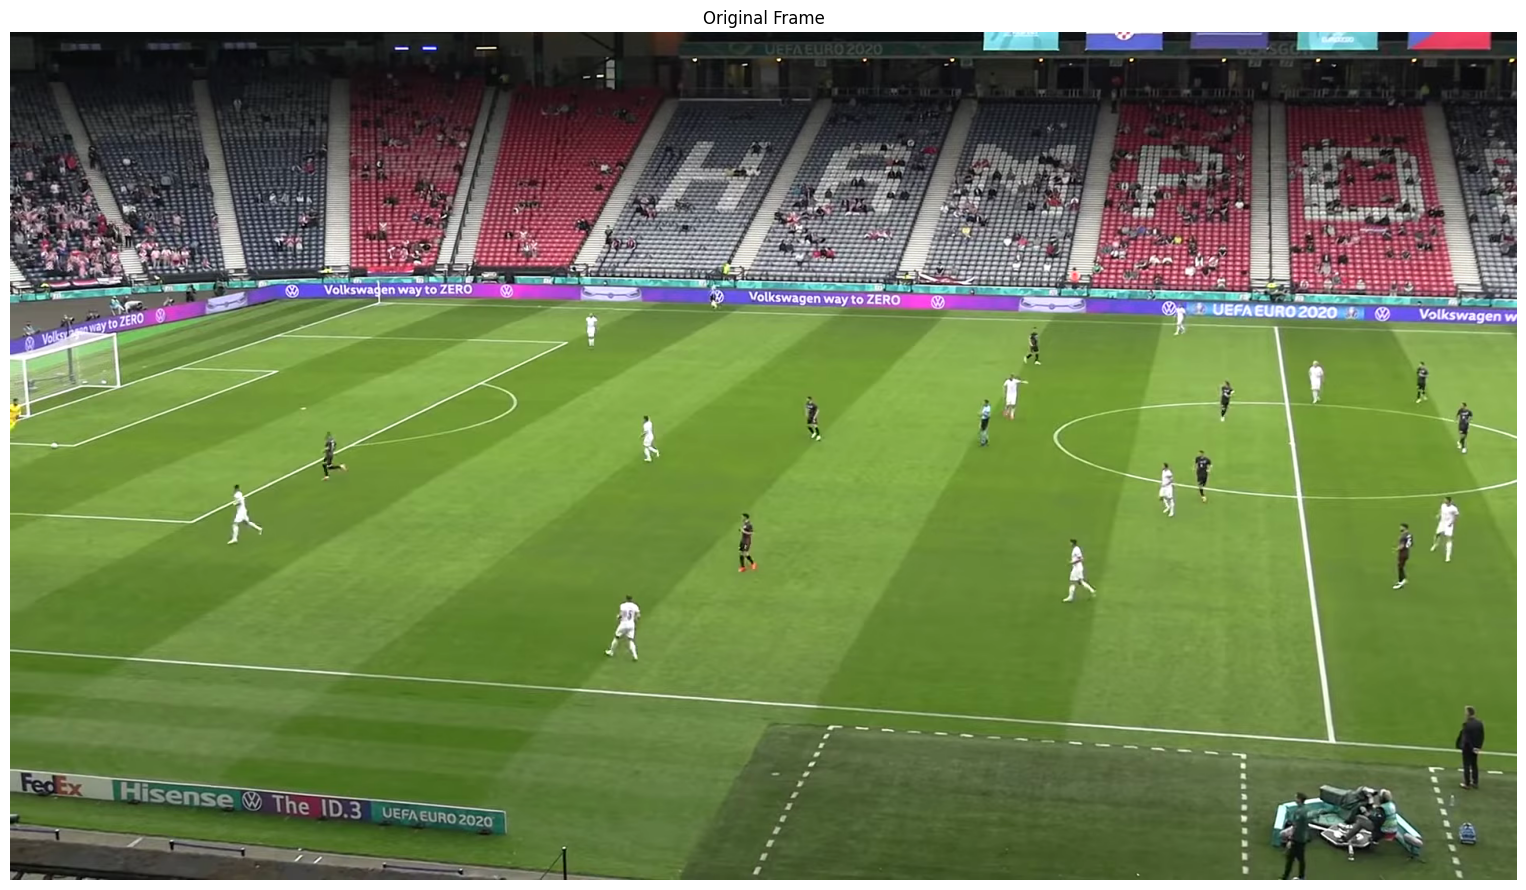

In [25]:
plt.figure(figsize=(16, 9))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title('Original Frame')
plt.axis('off')
plt.tight_layout()
plt.show()

### Run Pipeline

This runs the full pipeline on the single test frame.

In [26]:
result = pipeline.process_frame(frame, frame_idx=frame_num)

H = result['H']
H_info = result['H_info']
player_xyxy = result['player_xyxy']
player_conf = result['player_conf']
used_kpts = result['keypoints_used']
player_pitch_pts = result['player_pitch_pts']
team_info = result['team_info']

# Ball detection results
ball_xyxy = result.get('ball_xyxy', np.empty((0, 4)))
ball_conf = result.get('ball_conf', np.empty((0,)))
ball_pitch_pt = result.get('ball_pitch_pt', None)
ball_trajectory = result.get('ball_trajectory', [])
has_ball = len(ball_xyxy) > 0

print(f"Homography mode:   {H_info.get('mode', 'N/A')}")
print(f"Keypoints used:    {len(used_kpts)}")
print(f"Inliers:           {H_info.get('inliers', 0)} / {H_info.get('total_points', 0)}")
print(f"Players detected:  {len(player_pitch_pts)}")
print(f"Ball detected:     {'YES (conf=' + str(ball_conf[0])[:5] + ')' if has_ball else 'No'}")
if has_ball and ball_pitch_pt is not None:
    print(f"Ball pitch pos:    ({ball_pitch_pt[0]:.2f}m, {ball_pitch_pt[1]:.2f}m)")
print(f"Ball trajectory:   {len(ball_trajectory)} positions")

if H is None:
    print("\n⚠️  Could not compute homography on this frame.")
else:
    print("\n✅ Homography computed successfully.")

if team_info is not None and len(team_info.get('team_ids', [])) > 0:
    n_team1 = int((team_info['team_ids'] == 0).sum())
    n_team2 = int((team_info['team_ids'] == 1).sum())
    n_gk = int((team_info['team_ids'] == -1).sum())
    n_ref = int((team_info['team_ids'] == -2).sum())
    print(f"\n🎨 Teams: Team1={n_team1}, Team2={n_team2}, GK={n_gk}, Ref={n_ref}")

NOTHING REMOVED
Homography mode:   keypoint-ransac
Keypoints used:    5
Inliers:           5 / 5
Players detected:  23
Ball detected:     No
Ball trajectory:   0 positions

✅ Homography computed successfully.

🎨 Teams: Team1=5, Team2=3, GK=0, Ref=15


## Output Visualizations

### 1. Annotated Frame (Keypoints + Team Bboxes + Ball + Segmentation Overlay)

The original frame with:
- **Yellow dots**: Keypoints used for homography (with labels)
- **Colored polygons**: Segmentation masks (deep analysis)
- **Team-colored bboxes**: Semi-transparent bounding boxes colored by team
- **Green ball bbox**: Ball detection bounding box with confidence label

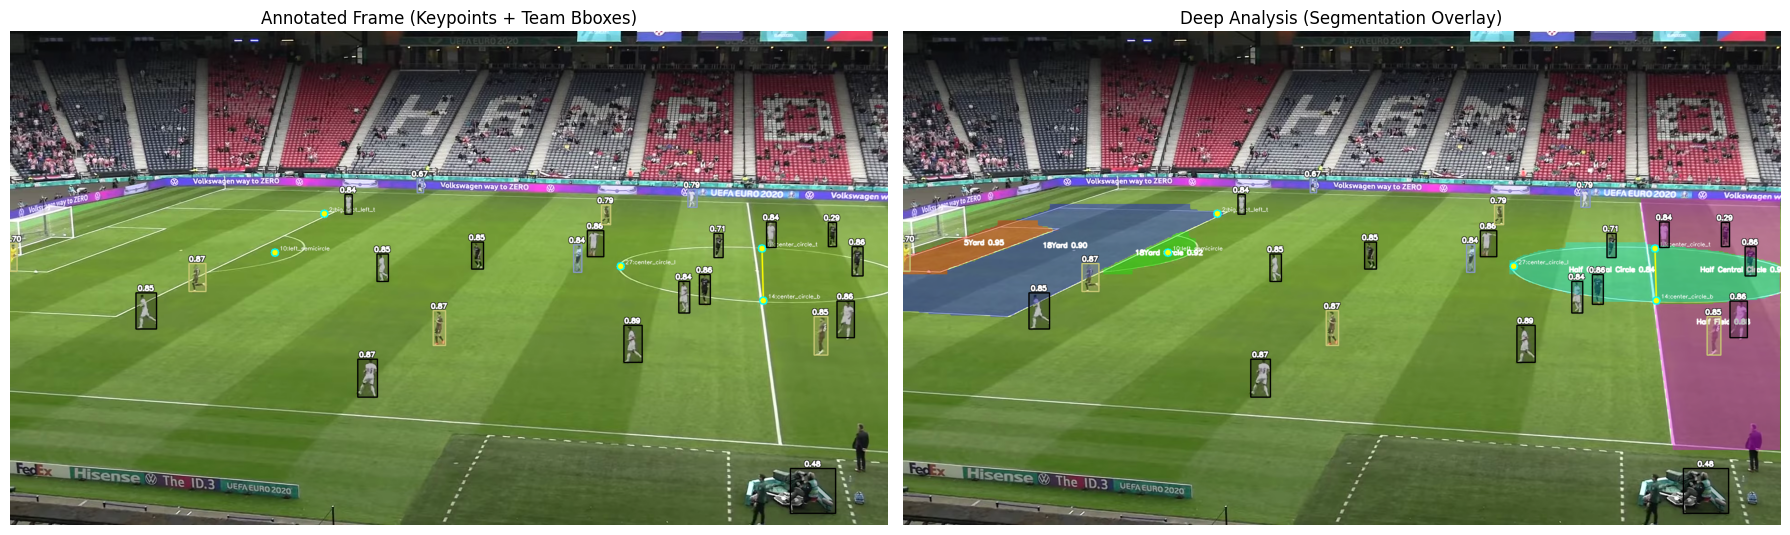

In [27]:
plt.figure(figsize=(18, 10))

plt.subplot(1, 2, 1)
annotated = result['annotated_frame']
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title('Annotated Frame (Keypoints + Team Bboxes)')
plt.axis('off')

plt.subplot(1, 2, 2)
deep_analysis = result['deep_analysis_frame']
plt.imshow(cv2.cvtColor(deep_analysis, cv2.COLOR_BGR2RGB))
plt.title('Deep Analysis (Segmentation Overlay)')
plt.axis('off')

plt.tight_layout()
plt.show()


### 2. Top-Down Pitch Canvas (Team-Colored + Ball + Trajectory)

Bird's-eye view of the pitch with players projected via the homography.
Players are colored by team. A legend in the top-right shows the team colors.
The **ball** is shown as a bright yellow dot with **white outline**.
A fading **trajectory trail** shows the last 50 ball positions (orange → red).

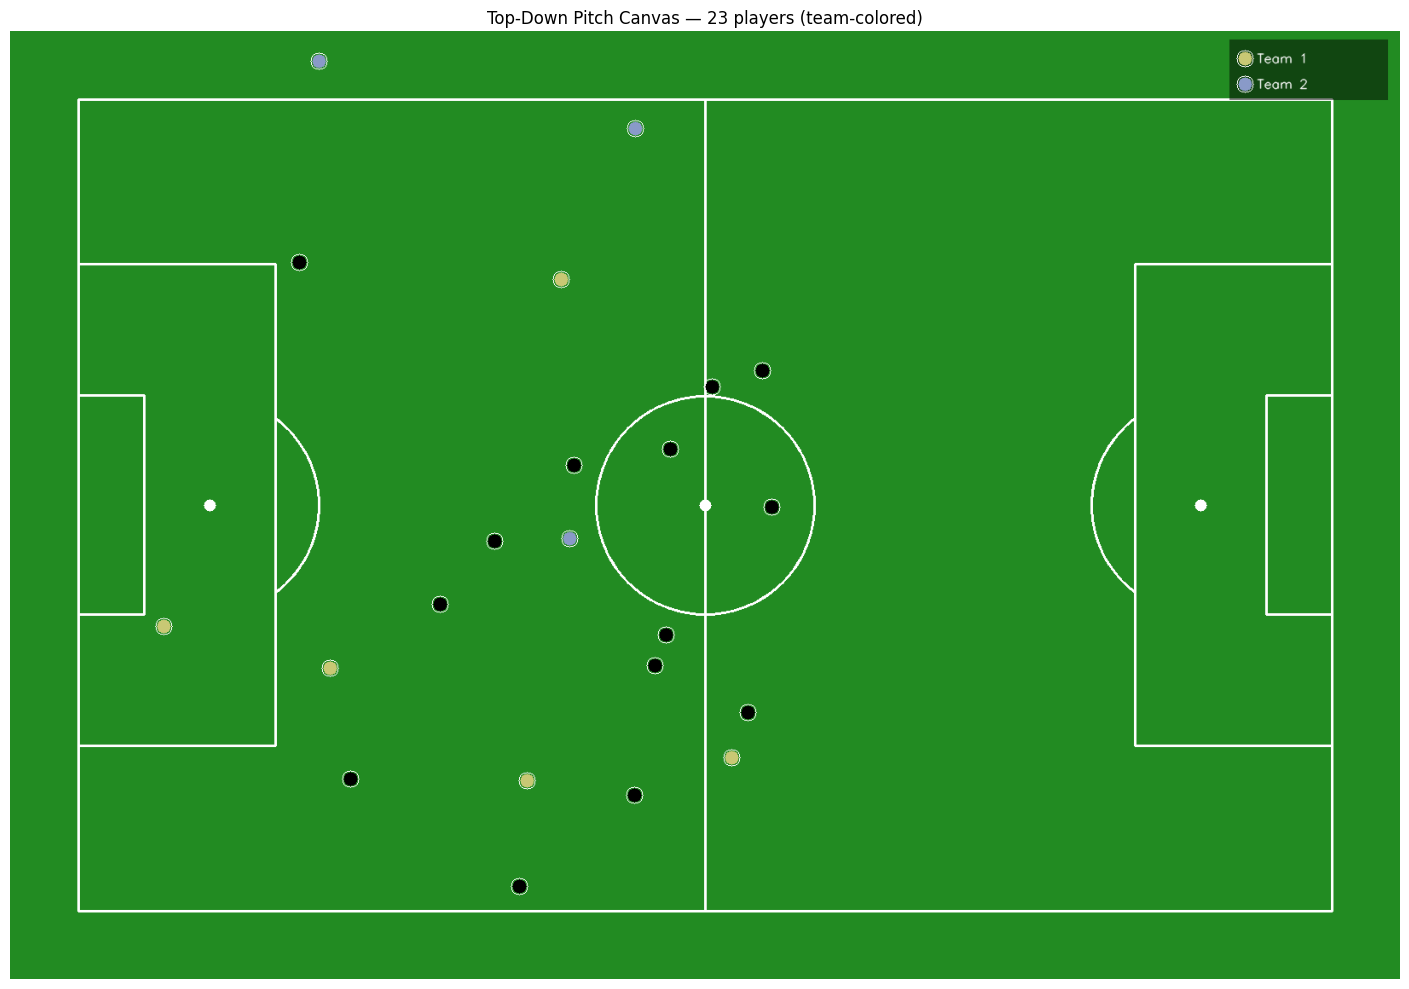

In [28]:
pitch_canvas = result['pitch_canvas']
plt.figure(figsize=(16, 10))
plt.imshow(cv2.cvtColor(pitch_canvas, cv2.COLOR_BGR2RGB))
plt.title(f'Top-Down Pitch Canvas — {len(player_pitch_pts)} players (team-colored)')
plt.axis('off')
plt.tight_layout()
plt.show()

### 3. Keypoint Details

List all keypoints used in the homography computation.

In [29]:
print(f"{'ID':<4} {'Name':<30} {'Image (x,y)':<25} {'Pitch (x,y)':<20} {'Conf':<6}")
print('-' * 85)
for kp in used_kpts:
    img_pt = f"({kp['image_pt'][0]:.1f}, {kp['image_pt'][1]:.1f})"
    pitch_pt = f"({kp['pitch_pt'][0]:.2f}, {kp['pitch_pt'][1]:.2f})"
    print(f"{kp['kpt_id']:<4} {kp['name']:<30} {img_pt:<25} {pitch_pt:<20} {kp['confidence']:<6.1f}")

ID   Name                           Image (x,y)               Pitch (x,y)          Conf  
-------------------------------------------------------------------------------------
2    big_rect_left_top_pt2          (687.3, 399.4)            (16.50, 13.84)       0.9   
27   center_circle_left             (1335.9, 514.5)           (43.35, 34.00)       0.9   
10   left_semicircle_right          (579.1, 484.5)            (20.15, 34.00)       0.8   
13   center_circle_top              (1644.1, 476.0)           (52.50, 24.85)       0.8   
14   center_circle_bottom           (1647.5, 589.5)           (52.50, 43.15)       0.8   


### 4. Team Color Details

Shows the team assignment for each detected player.

In [30]:
if team_info is not None and len(team_info.get('team_ids', [])) > 0:
    team_ids = team_info['team_ids']
    colors = team_info['team_colors']
    print(f"{'#':<4} {'Team':<10} {'BGR Color':<20} {'Conf':<8}")
    print('-' * 42)
    for i in range(min(len(team_ids), len(player_conf))):
        tid = team_ids[i]
        label = 'GK' if tid == -1 else ('Ref' if tid == -2 else f'Team {tid+1}')
        c = colors[i] if i < len(colors) else (128, 128, 128)
        color_str = f"({int(c[0])}, {int(c[1])}, {int(c[2])})"
        print(f"{i:<4} {label:<10} {color_str:<20} {player_conf[i]:.3f}")
else:
    print("No players detected or team analysis not available.")

#    Team       BGR Color            Conf    
------------------------------------------
0    Ref        (0, 0, 0)            0.887
1    Team 1     (116, 200, 200)      0.875
2    Team 1     (116, 200, 200)      0.875
3    Ref        (0, 0, 0)            0.868
4    Ref        (0, 0, 0)            0.862
5    Ref        (0, 0, 0)            0.860
6    Ref        (0, 0, 0)            0.858
7    Ref        (0, 0, 0)            0.857
8    Ref        (0, 0, 0)            0.853
9    Ref        (0, 0, 0)            0.851
10   Team 1     (116, 200, 200)      0.851
11   Ref        (0, 0, 0)            0.848
12   Ref        (0, 0, 0)            0.843
13   Ref        (0, 0, 0)            0.839
14   Ref        (0, 0, 0)            0.837
15   Team 2     (200, 154, 137)      0.837
16   Team 2     (200, 154, 137)      0.792
17   Team 1     (116, 200, 200)      0.791
18   Ref        (0, 0, 0)            0.713
19   Team 1     (116, 200, 200)      0.696
20   Team 2     (200, 154, 137)      0.674
21   Ref

### 5. Ball Detection Details

Shows the ball detection status, confidence, and pitch position.

In [31]:
if has_ball:
    print(f"⚽ Ball detected!")
    print(f"   Bounding box: x1={ball_xyxy[0][0]:.1f}, y1={ball_xyxy[0][1]:.1f}, x2={ball_xyxy[0][2]:.1f}, y2={ball_xyxy[0][3]:.1f}")
    print(f"   Confidence:    {ball_conf[0]:.3f}")
    if ball_pitch_pt is not None:
        print(f"   Pitch position: ({ball_pitch_pt[0]:.2f}m, {ball_pitch_pt[1]:.2f}m)")
    print(f"   Trajectory:     {len(ball_trajectory)} positions stored")
else:
    print("No ball detected in this frame.")
    print("Try a different frame where the ball might be visible.")

No ball detected in this frame.
Try a different frame where the ball might be visible.


### 6. Ball on Pitch Canvas

The ball appears as a **yellow dot** on the pitch canvas above. If you process a video,
the trajectory trail will accumulate over frames, showing the ball's path.
The ball bounding box appears on the annotated frame as a **green rectangle** with a `Ball 0.XX` label.

## Process Full Video

Process the entire video and generate five output videos:
- `full_pitch_debug_map.mp4` — Top-down pitch view with **ball + trajectory + team-colored dots**
- `annotated_video.mp4` — Original frame with keypoints + **team-colored bboxes + ball bbox**
- `deep_analysis.mp4` — Original frame with segmentation overlay + **team-colored bboxes + ball bbox**
- `final_draft.mp4` — Original frame with the pitch debug map **overlayed** as a picture-in-picture (with ball + trail)
- `keypoint_annotations.mp4` — Original frame with keypoint skeleton overlays only (debug: no bboxes)

In [32]:
# Process a limited number of frames for quick testing
FRAMES_TO_PROCESS = None  # Set to None for all frames
START_FRAME = 0

print(f"Processing {FRAMES_TO_PROCESS or 'all'} frames starting from frame {START_FRAME}...")
print(f"  Smoothing: alpha={SMOOTHING_ALPHA}, stability={H_STABILITY_THRESHOLD}")
print(f"  Team colors: enabled")

for i, frame_result in enumerate(pipeline.process_video(
    source_video_path=SOURCE_VIDEO_PATH,
    output_dir=str(OUTPUT_DIR),
    start_frame=START_FRAME,
    max_frames=FRAMES_TO_PROCESS,
    process_every_n=1,
)):
    pass  # Processing happens in the generator

print("\nVideo processing complete!")

Processing all frames starting from frame 0...
  Smoothing: alpha=0.4, stability=0.15
  Team colors: enabled
Video: 25.0FPS, 1920x1080, 1500 frames
Processing from frame 0, max_frames=None
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
  Frame 29: H=fallback-last, kpts=3, players=23, ball=no
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NOTHING REMOVED
NO

## Summary

**Pipeline architecture**:
```
Frame → Keypoint Model → 29 keypoints → filter → RANSAC → H matrix
                                                       ↓ EMA smoothing
                                                       ↓ 
Frame → Player Model → bboxes → bottom-center → perspectiveTransform(H) → pitch coords
                       ↓                ↓
              TeamColorAnalyzer    Team-colored dots + bboxes
                (K-means k=2)
                            ↓
Frame → Ball Model → bbox → bottom-center → perspectiveTransform(H) → ball on pitch
                       ↓                                ↓
              Green ball bbox on frame        Trajectory trail on pitch
                            ↓
Frame → Segmentation Model → masks → overlay on original frame (deep analysis)
```

**Features**:
- `SMOOTHING_ALPHA=0.4` — EMA blend factor for homography smoothing (reduces jitter)
- `H_STABILITY_THRESHOLD=0.15` — Max relative change before rejecting unstable H
- `TeamColorAnalyzer` — K-means (k=2) on jersey colors for team segregation
- Team legend on pitch canvas + team-colored bounding boxes on frames
- `BallDetector` — Dedicated YOLO ball model (`yolo_11_best.pt`) with ball bbox, pitch dot, and trajectory trail

**Output videos**:
- `full_pitch_debug_map.mp4` — Top-down pitch view with team-colored dots + ball + trajectory
- `annotated_video.mp4` — Original frame with keypoints + team-colored bboxes + ball bbox
- `deep_analysis.mp4` — Original frame with segmentation overlay + team bboxes + ball
- `final_draft.mp4` — Original frame with pitch debug map overlayed as PIP (includes ball)
- `keypoint_annotations.mp4` — Original frame with keypoint skeleton overlays only (debug)

**Key files**:
- `app/keypoint_service.py` — `PitchKeypointMapper` + `KeypointHomographyComputer` + `_apply_homography_smoothing()`
- `app/team_analyzer.py` — `TeamColorAnalyzer`
- `app/ball_service.py` — `BallDetector` (new)
- `app/keypoint_pipeline.py` — `KeypointPipeline` orchestrator (updated with ball)
- `app/pitch.py` — `draw_players_on_pitch()` + `draw_ball_on_pitch()` + `draw_ball_trajectory()` (updated)
- `app/constants.py` — Configuration with smoothing + color analysis + ball constants